In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder,LabelEncoder

In [ ]:
df=pd.read_csv('/content/gaming_addiction.csv')

In [ ]:
df.head()

,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,...,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.0,0.920,1.000
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,...,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.0,0.515,0.813
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,...,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.0,0.720,0.947
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,...,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.0,0.520,0.660
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,...,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.0,0.585,0.867


In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'occupation', 'income_level',
       'years_gaming', 'preferred_genre', 'platform', 'device_type',
       'rank_tier', 'daily_playtime_hours', 'weekly_play_sessions',
       'late_night_sessions_hours', 'weekend_playtime_hours',
       'consecutive_hours_max', 'multiplayer_ratio', 'toxic_chat_reports',
       'rage_quit_frequency', 'in_game_purchases', 'monthly_spending_usd',
       'lootbox_openings', 'subscription_status', 'stress_score',
       'loneliness_score', 'dopamine_dependency_index', 'self_control_score',
       'impulsiveness_score', 'anxiety_level', 'depression_indicator',
       'emotional_stability', 'sleep_hours', 'exercise_frequency_per_week',
       'caffeine_intake_cups_day', 'social_interaction_hours',
       'relationship_status', 'gpa_or_performance_score', 'missed_deadlines',
       'productivity_drop_percent', 'absenteeism_days', 'internet_speed_mbps',
       'screen_time_total_hours', 'behavioral_cluster', 'addicti

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 49 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      250 non-null    object 
 1   age                          250 non-null    int64  
 2   gender                       250 non-null    object 
 3   country                      250 non-null    object 
 4   occupation                   250 non-null    object 
 5   income_level                 250 non-null    object 
 6   years_gaming                 250 non-null    int64  
 7   preferred_genre              250 non-null    object 
 8   platform                     250 non-null    object 
 9   device_type                  250 non-null    object 
 10  rank_tier                    250 non-null    object 
 11  daily_playtime_hours         250 non-null    float64
 12  weekly_play_sessions         250 non-null    int64  
 13  late_night_sessions_

In [ ]:
df.shape

(250, 49)

(250, 49)

In [ ]:
df.describe()

,age,years_gaming,daily_playtime_hours,weekly_play_sessions,late_night_sessions_hours,weekend_playtime_hours,consecutive_hours_max,multiplayer_ratio,toxic_chat_reports,rage_quit_frequency,...,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,addiction_score,addiction_binary,burnout_probability,mental_health_risk_score,churn_probability
count,250.000000,250.000000,250.000000,250.000000,250.0000,250.000000,250.000000,250.000000,250.000000,250.000000,...,250.000000,250.000000,250.00000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,22.160000,9.668000,6.153200,7.056000,2.1024,8.368400,9.714800,0.462240,2.948000,1.896000,...,2.828000,15.986400,5.52400,99.253200,8.239600,38.74448,0.168000,0.996856,0.509640,0.795556
std,5.455037,5.460866,2.656902,3.517721,1.2007,4.085876,4.828877,0.227391,5.451621,2.353581,...,2.088027,10.581607,3.14212,55.057918,2.894558,11.74977,0.374616,0.043240,0.140448,0.120904
min,13.000000,1.000000,0.500000,1.000000,0.0000,0.500000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,5.000000,1.200000,12.28000,0.000000,0.320000,0.120000,0.150000
25%,18.000000,6.000000,4.225000,4.000000,1.1250,5.600000,5.525000,0.300000,0.000000,0.000000,...,1.000000,8.150000,3.00000,61.375000,6.200000,29.88250,0.000000,1.000000,0.406250,0.732250
50%,22.000000,9.000000,6.450000,7.000000,2.1000,8.150000,10.100000,0.450000,1.000000,1.000000,...,3.000000,15.900000,6.00000,99.150000,8.200000,39.87500,0.000000,1.000000,0.515000,0.808000
75%,27.000000,14.750000,8.175000,10.000000,3.0000,10.850000,13.175000,0.630000,2.000000,3.000000,...,4.000000,22.975000,8.00000,133.575000,10.500000,47.11000,0.000000,1.000000,0.600000,0.878000
max,40.000000,25.000000,11.900000,15.000000,5.2000,20.000000,20.600000,1.000000,32.000000,10.000000,...,8.000000,44.200000,14.00000,255.500000,15.100000,68.00000,1.000000,1.000000,0.920000,1.000000


In [ ]:
df.nunique()

,0
user_id,250
age,25
gender,4
country,15
occupation,5
income_level,5
years_gaming,23
preferred_genre,10
platform,5
device_type,6


In [ ]:
df['gender'].unique()

array(['Male', 'Female', 'Non-binary', 'Prefer not to say'], dtype=object)

In [ ]:
df['gender'].value_counts()

,count
gender,
Male,158
Female,66
Non-binary,18
Prefer not to say,8


In [ ]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
occupation,0
income_level,0
years_gaming,0
preferred_genre,0
platform,0
device_type,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop(columns=['user_id','country','subscription_status','gender','addiction_score','addiction_severity','toxic_chat_reports','burnout_probability','income_level','churn_probability','behavioral_cluster'],inplace=True)


In [ ]:
df.isnull().sum()

,0
age,0
occupation,0
years_gaming,0
preferred_genre,0
platform,0
device_type,0
rank_tier,0
daily_playtime_hours,0
weekly_play_sessions,0
late_night_sessions_hours,0


In [ ]:
df.isnull().sum()

,0
age,0
occupation,0
years_gaming,0
preferred_genre,0
platform,0
device_type,0
rank_tier,0
daily_playtime_hours,0
weekly_play_sessions,0
late_night_sessions_hours,0


In [ ]:
df['depression_indicator']=df['depression_indicator'].fillna(df['depression_indicator'].mean())
df['gpa_or_performance_score']=df['gpa_or_performance_score'].fillna(df['gpa_or_performance_score'].mean())

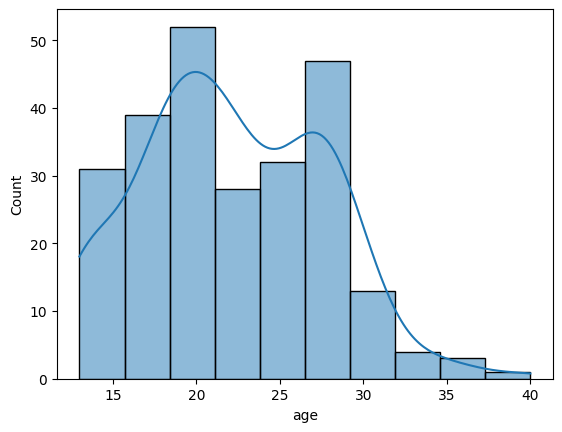

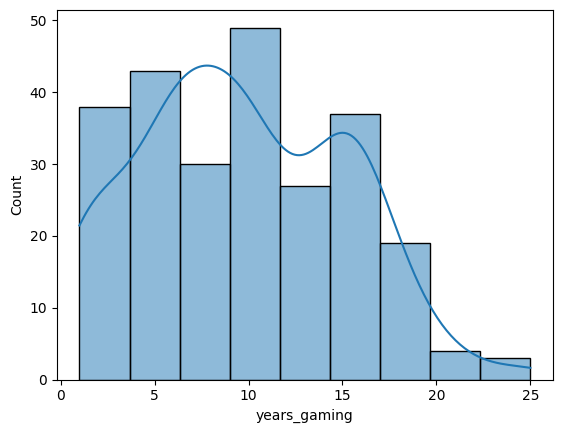

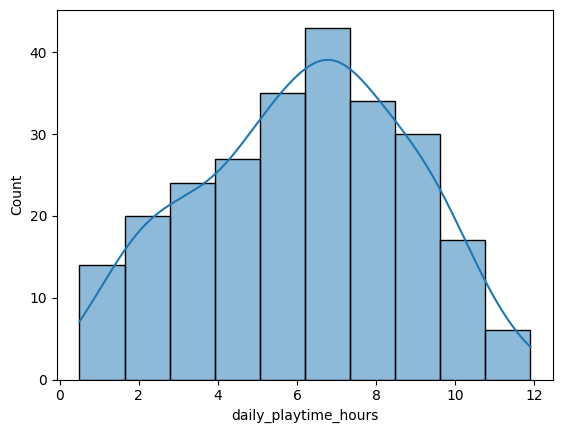

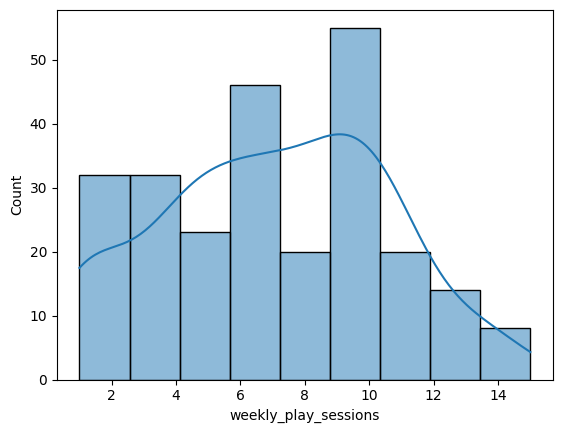

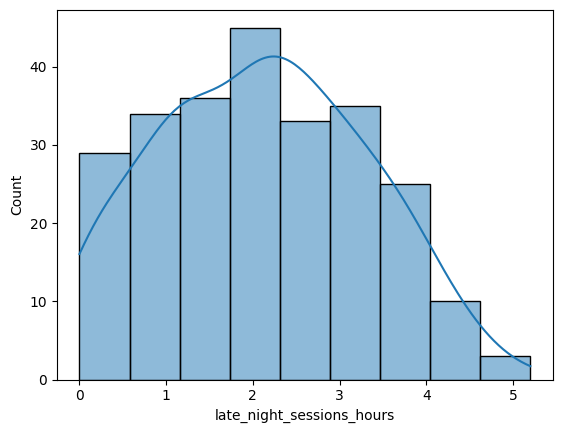

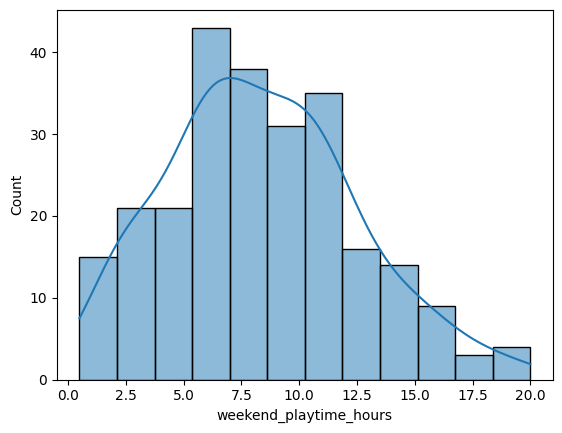

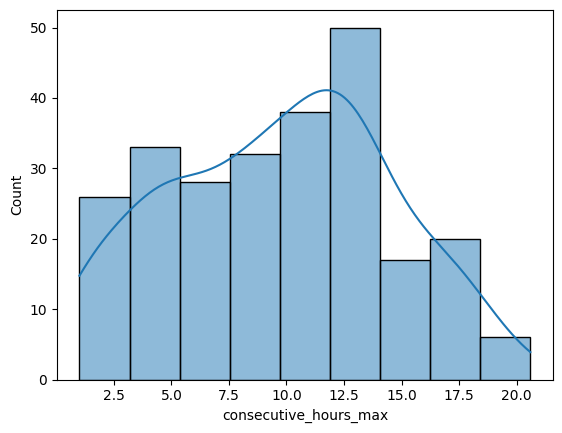

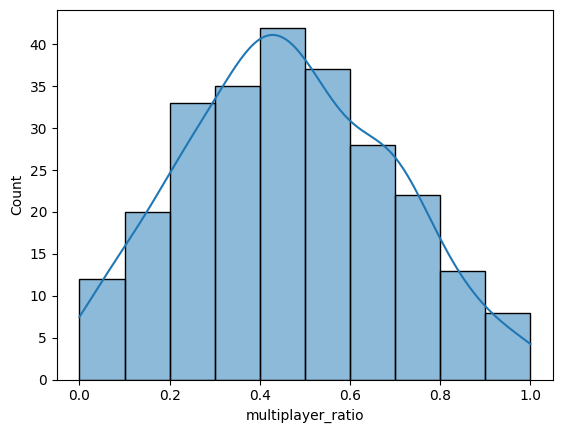

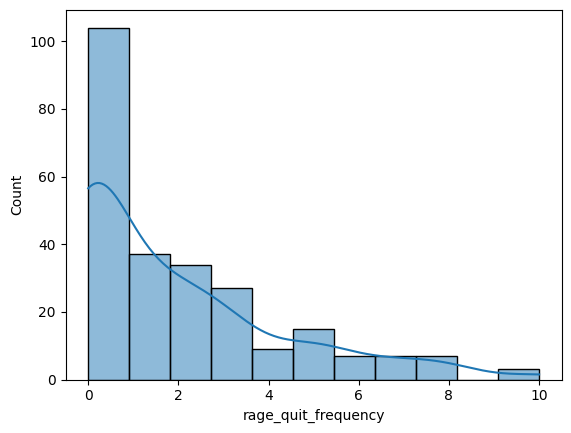

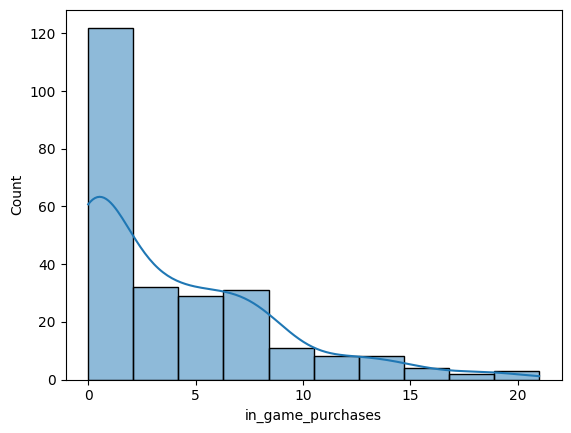

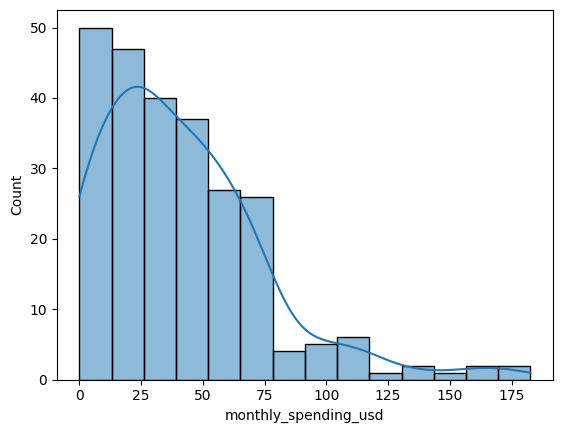

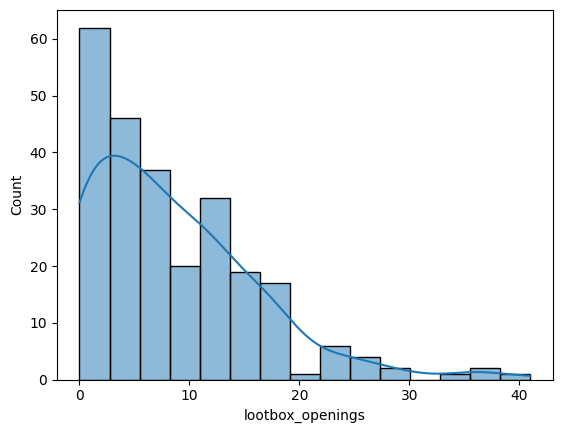

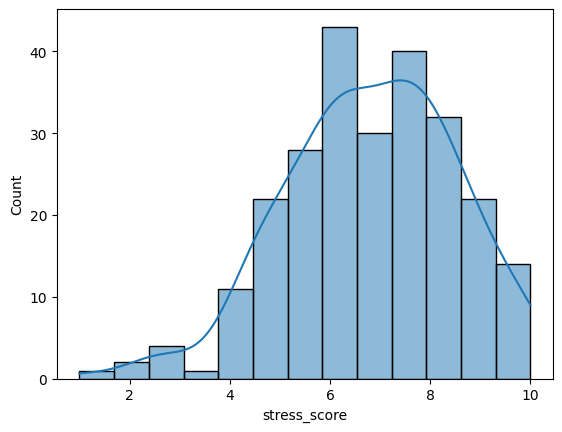

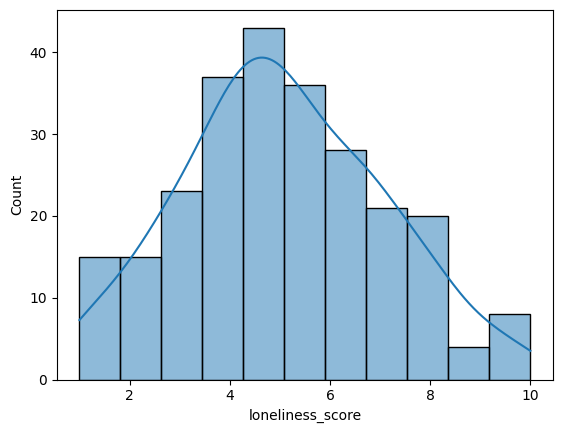

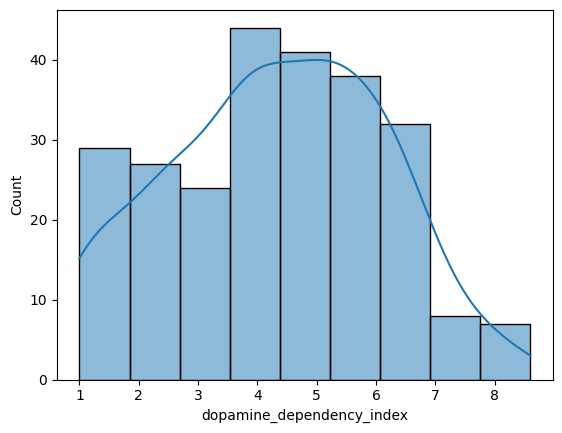

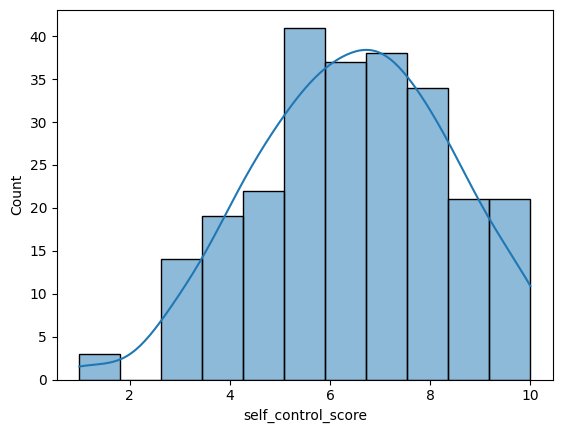

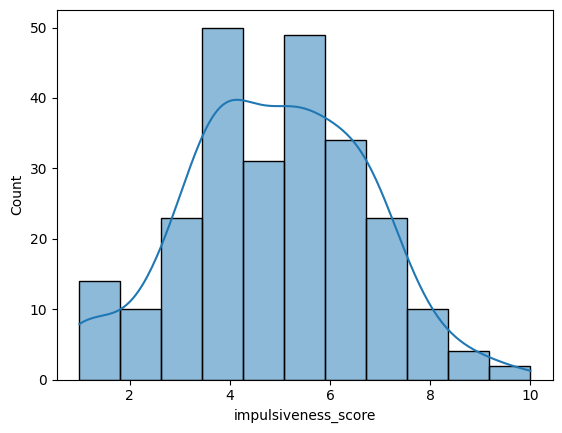

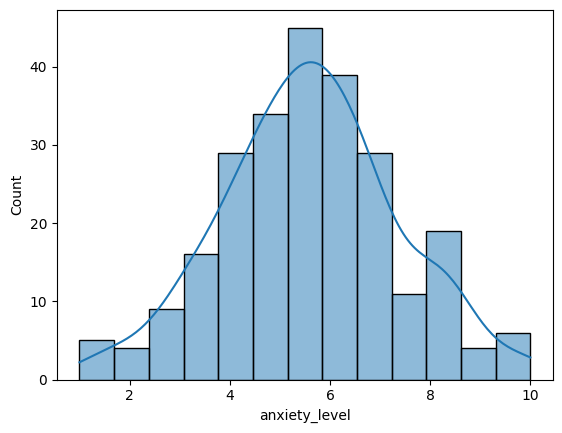

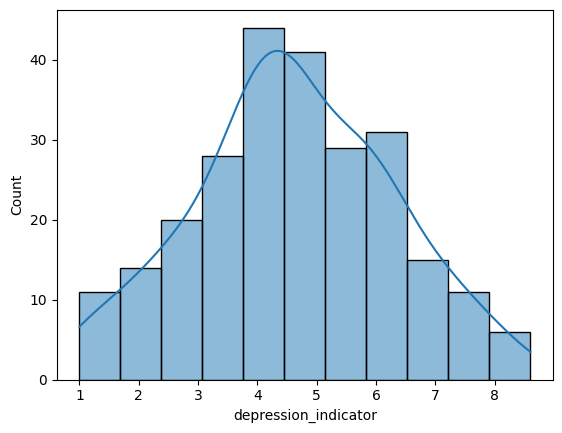

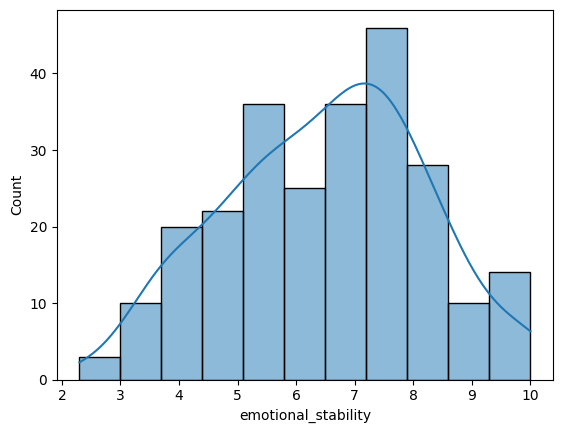

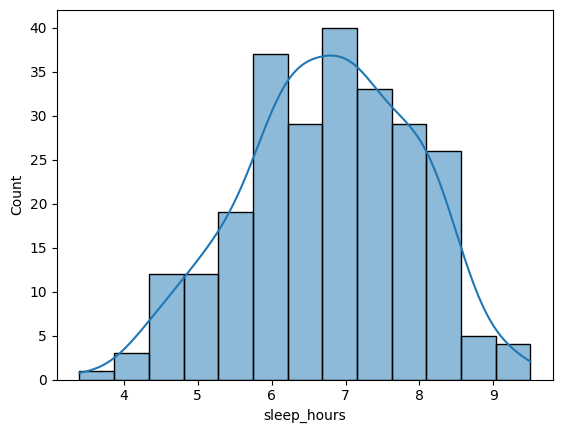

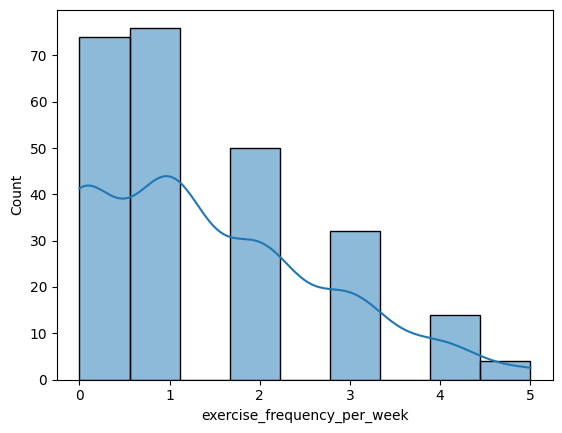

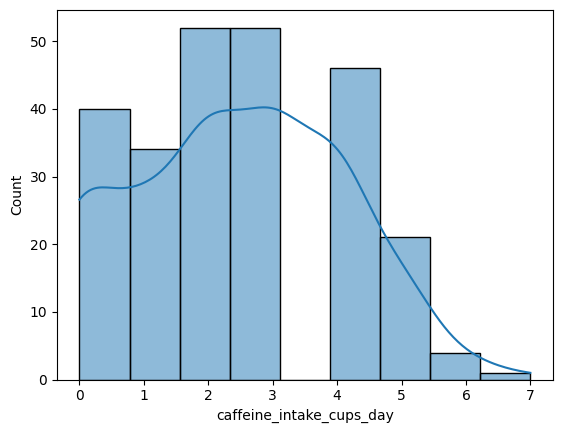

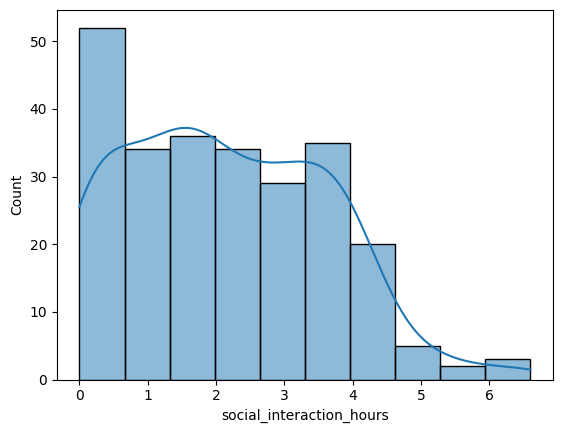

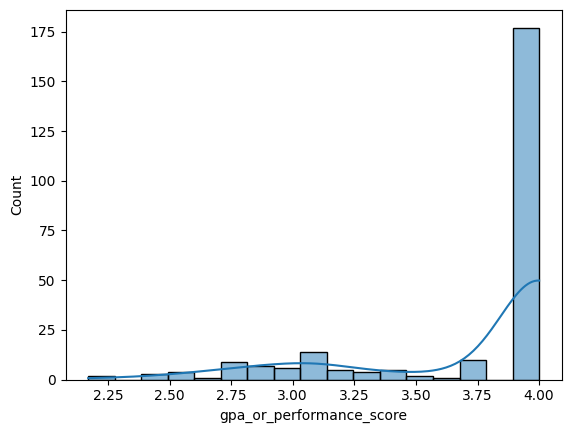

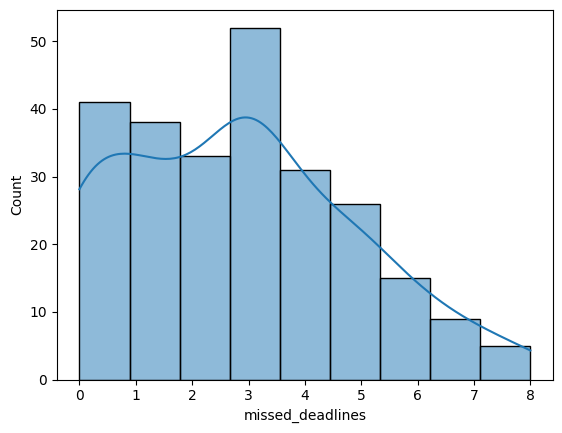

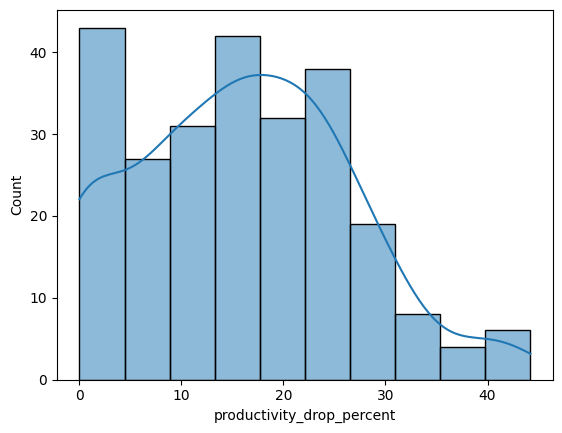

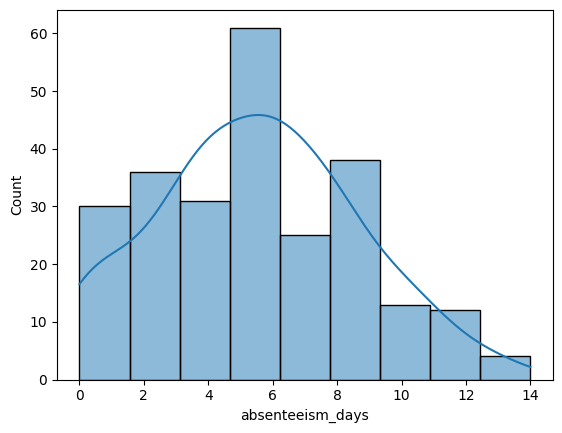

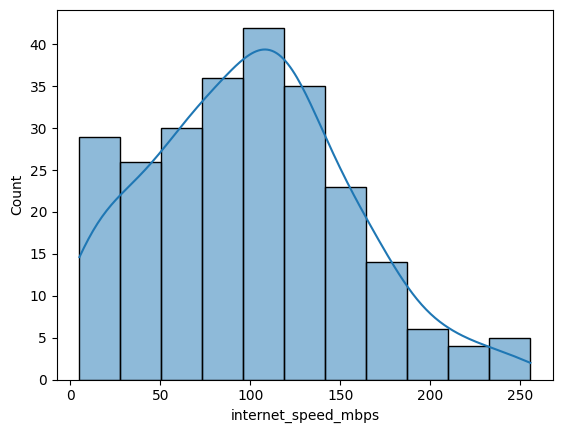

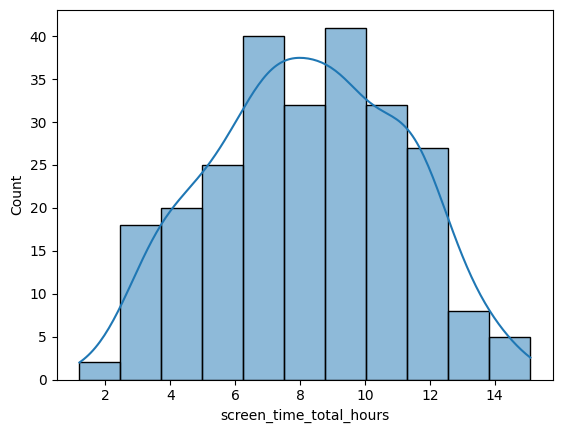

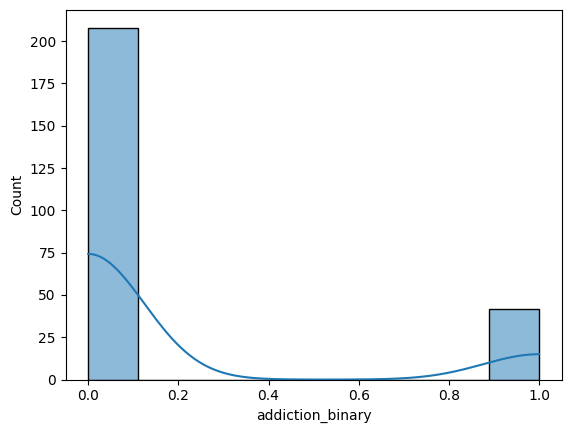

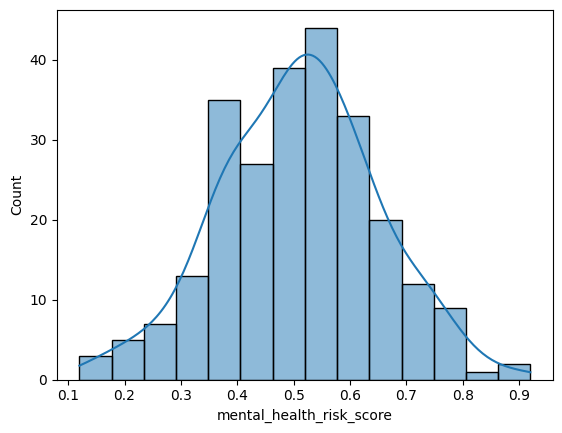

In [ ]:
num=df.select_dtypes(include=['int64','float64'])
cat=df.select_dtypes(include=['object'])


for col in num.columns:
  sns.histplot(data=df,x=col,kde=True)
  plt.show()

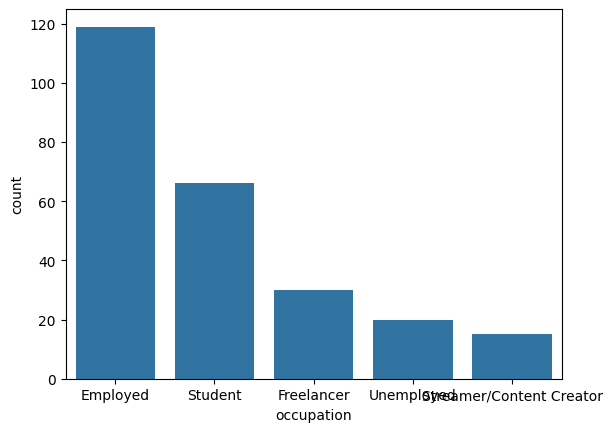

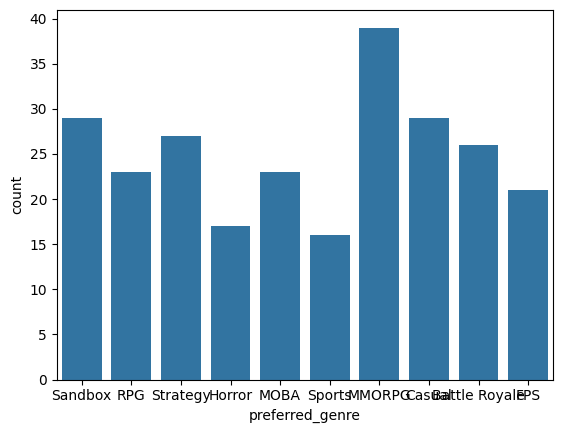

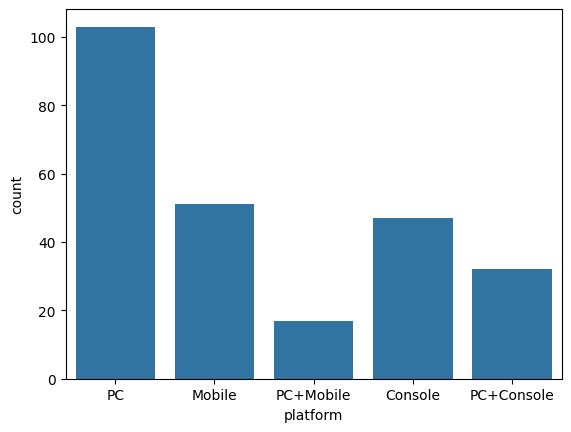

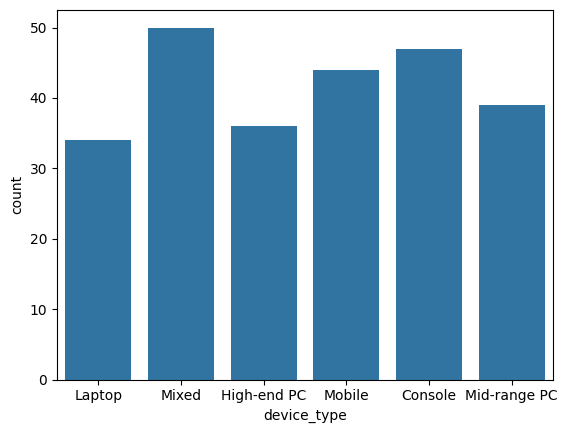

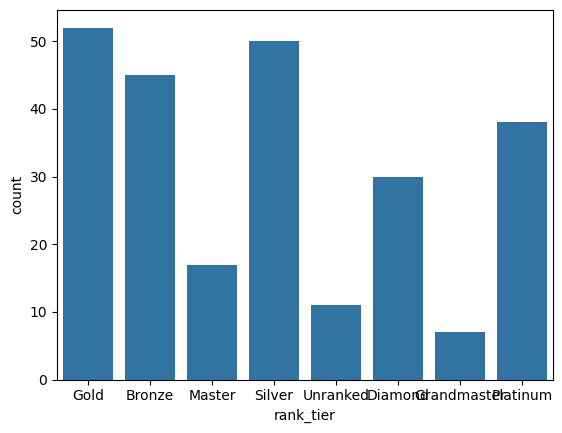

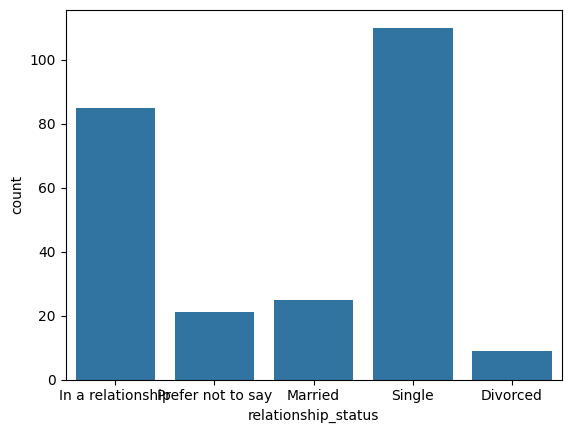

In [ ]:
for col in cat.columns:
  sns.countplot(data=df,x=col)
  plt.show()

In [ ]:
for col in cat.columns:
    print(f"Column: {col} -> Unique values: {cat[col].nunique()}")
    print("-------------------")

Column: occupation -> Unique values: 5
-------------------
Column: preferred_genre -> Unique values: 10
-------------------
Column: platform -> Unique values: 5
-------------------
Column: device_type -> Unique values: 6
-------------------
Column: rank_tier -> Unique values: 8
-------------------
Column: relationship_status -> Unique values: 5
-------------------


In [ ]:
df

,age,occupation,years_gaming,preferred_genre,platform,device_type,rank_tier,daily_playtime_hours,weekly_play_sessions,late_night_sessions_hours,...,social_interaction_hours,relationship_status,gpa_or_performance_score,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,addiction_binary,mental_health_risk_score
0,21,Employed,9,Sandbox,PC,Laptop,Gold,3.5,4,1.0,...,2.7,In a relationship,4.000000,4,0.0,7,39.9,5.4,0,0.920
1,25,Employed,13,RPG,Mobile,Mixed,Bronze,10.9,14,3.2,...,3.5,In a relationship,4.000000,4,16.7,6,71.5,13.4,1,0.515
2,26,Employed,14,RPG,PC+Mobile,High-end PC,Master,8.6,7,2.4,...,2.0,Prefer not to say,4.000000,6,8.5,7,119.4,12.3,0,0.720
3,22,Employed,10,Strategy,PC+Mobile,Mobile,Bronze,5.9,5,1.1,...,0.6,Married,4.000000,3,8.7,8,136.5,6.9,0,0.520
4,17,Student,5,Strategy,PC,Laptop,Bronze,7.4,8,3.2,...,1.2,Single,2.600000,3,21.9,6,78.8,9.3,0,0.585
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,23,Streamer/Content Creator,11,MMORPG,PC+Console,Console,Platinum,6.7,7,0.5,...,1.7,Single,4.000000,1,17.6,4,180.9,7.2,0,0.395
246,18,Student,6,Sandbox,PC,Mid-range PC,Bronze,2.3,1,0.4,...,4.4,In a relationship,2.730000,0,0.0,0,91.5,5.6,0,0.715
247,20,Student,8,MMORPG,Mobile,Console,Bronze,3.3,5,2.4,...,1.2,Single,2.800000,1,0.0,8,120.6,4.9,0,0.410
248,19,Employed,7,Sandbox,PC+Console,High-end PC,Silver,4.6,4,0.8,...,1.2,In a relationship,3.732333,2,23.8,2,175.9,5.2,0,0.405


In [ ]:
corrs = df.corr(numeric_only=True)['addiction_binary'].sort_values(key=abs, ascending=False)
print(corrs)

addiction_binary               1.000000
daily_playtime_hours           0.517546
late_night_sessions_hours      0.499097
dopamine_dependency_index      0.492680
screen_time_total_hours        0.471983
weekend_playtime_hours         0.454512
consecutive_hours_max          0.453292
weekly_play_sessions           0.419491
sleep_hours                   -0.369800
self_control_score            -0.311446
impulsiveness_score            0.303039
absenteeism_days               0.279745
productivity_drop_percent      0.269259
missed_deadlines               0.206521
exercise_frequency_per_week   -0.180741
stress_score                   0.150947
monthly_spending_usd           0.146188
lootbox_openings               0.115110
loneliness_score              -0.111721
gpa_or_performance_score       0.095672
in_game_purchases              0.089168
caffeine_intake_cups_day       0.084858
social_interaction_hours       0.055851
emotional_stability           -0.051514
multiplayer_ratio             -0.034609


In [ ]:
cat

,occupation,preferred_genre,platform,device_type,rank_tier,relationship_status
0,Employed,Sandbox,PC,Laptop,Gold,In a relationship
1,Employed,RPG,Mobile,Mixed,Bronze,In a relationship
2,Employed,RPG,PC+Mobile,High-end PC,Master,Prefer not to say
3,Employed,Strategy,PC+Mobile,Mobile,Bronze,Married
4,Student,Strategy,PC,Laptop,Bronze,Single
...,...,...,...,...,...,...
245,Streamer/Content Creator,MMORPG,PC+Console,Console,Platinum,Single
246,Student,Sandbox,PC,Mid-range PC,Bronze,In a relationship
247,Student,MMORPG,Mobile,Console,Bronze,Single
248,Employed,Sandbox,PC+Console,High-end PC,Silver,In a relationship


In [ ]:
X=df.drop(columns=['addiction_binary'])
y=df['addiction_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for col in cat.columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])


In [ ]:
X_train.shape

(200, 37)

In [ ]:
y_train.shape

(200,)

In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:
scale=StandardScaler()

In [ ]:
X_train_scale=scale.fit_transform(X_train)
X_test_scale=scale.transform(X_test)

**Logistic regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [ ]:
model_logistic=LogisticRegression()

In [ ]:
model_logistic.fit(X_train_scale,y_train)
ypred_lo=model_logistic.predict(X_test_scale)

In [ ]:
print(f'accuracy ={accuracy_score(y_test,ypred_lo)}')

accuracy =0.96


In [ ]:
print('accuracy of train data : ')

print(model_logistic.score(X_train_scale,y_train))

print('accuracy of test data : ')

print(model_logistic.score(X_test_scale,y_test))

accuracy of train data : 
0.995
accuracy of test data : 
0.96


In [ ]:
print('report of random forest model')
print(classification_report(y_test,ypred_lo))

report of random forest model
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        40
           1       0.83      1.00      0.91        10

    accuracy                           0.96        50
   macro avg       0.92      0.97      0.94        50
weighted avg       0.97      0.96      0.96        50



*Support Vectot Machine *

In [ ]:
from sklearn.svm import SVC

In [ ]:
model_Svc=SVC(kernel='rbf',C=1)

In [ ]:
model_Svc.fit(X_train_scale,y_train)
ypred_SC=model_Svc.predict(X_test_scale)

In [ ]:
print(accuracy_score(y_test,ypred_SC))

0.96


In [ ]:
print('accuracy of train data : ')

print(model_Svc.score(X_train_scale,y_train))

print('accuracy of test data : ')

print(model_Svc.score(X_test_scale,y_test))

accuracy of train data : 
0.985
accuracy of test data : 
0.96


In [ ]:
cm=confusion_matrix(y_test,ypred_SC)
print(f'confision matrix : \n{cm}')

confision matrix : 
[[40  0]
 [ 2  8]]


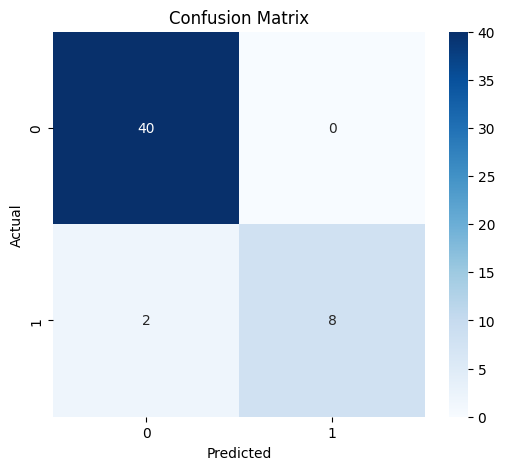

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_test, ypred_SC))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        40
           1       1.00      0.80      0.89        10

    accuracy                           0.96        50
   macro avg       0.98      0.90      0.93        50
weighted avg       0.96      0.96      0.96        50



**Decision Tree **

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text

In [ ]:
tree_overfit = DecisionTreeClassifier(random_state=42 ,max_depth=3 ,criterion='gini')

In [ ]:
tree_overfit.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
y_pred=tree_overfit.predict(X_test)

In [ ]:
print('Accuracy_score: ')
print(accuracy_score(y_test,y_pred))

Accuracy_score: 
0.94


In [ ]:
print('accuracy of test data : ')
print(tree_overfit.score(X_test,y_test))
print('accuracy of train data : ')
print(tree_overfit.score(X_train,y_train))

accuracy of test data : 
0.94
accuracy of train data : 
0.96


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        40
           1       0.82      0.90      0.86        10

    accuracy                           0.94        50
   macro avg       0.90      0.93      0.91        50
weighted avg       0.94      0.94      0.94        50



In [ ]:
cm=confusion_matrix(y_test,y_pred)
print(f'confision matrix : \n{cm}')

confision matrix : 
[[38  2]
 [ 1  9]]


**Random_forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_clf = RandomForestClassifier(n_estimators=120 , max_depth=5,criterion='gini' ,random_state=42)


In [ ]:
rf_clf.fit(X_train,y_train)

RandomForestClassifier(max_depth=5, n_estimators=120, random_state=42)

In [ ]:
y_pred_rf=rf_clf.predict(X_test)

In [ ]:
print(accuracy_score(y_test,y_pred_rf))

0.92


In [ ]:
print('accuracy of test data : ')
print(rf_clf.score(X_test,y_test))
print('accuracy of train data : ')
print(rf_clf.score(X_train,y_train))

accuracy of test data : 
0.92
accuracy of train data : 
1.0


In [ ]:
print('report of random forest model')
print(classification_report(y_test,y_pred_rf))

report of random forest model
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        40
           1       1.00      0.60      0.75        10

    accuracy                           0.92        50
   macro avg       0.95      0.80      0.85        50
weighted avg       0.93      0.92      0.91        50



KNN


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

scores = []

for k in range(1, 21):
    model_KNN = KNeighborsClassifier(n_neighbors=k)
    model_KNN.fit(X_train_scale, y_train)
    pred = model_KNN.predict(X_test_scale)
    scores.append(accuracy_score(y_test, pred))

In [ ]:
scores

[0.84,
 0.84,
 0.92,
 0.88,
 0.92,
 0.92,
 0.92,
 0.88,
 0.9,
 0.88,
 0.92,
 0.88,
 0.9,
 0.86,
 0.86,
 0.84,
 0.88,
 0.86,
 0.86,
 0.86]

In [ ]:
print('accuracy of test data : ')
print(model_KNN.score(X_test,y_test))
print('accuracy of train data : ')
print(model_KNN.score(X_train,y_train))

accuracy of test data : 
0.8
accuracy of train data : 
0.845


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


Ada Boast & Gride Search



In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

ada = AdaBoostClassifier(random_state=42)


ada_param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}


ada_grid = GridSearchCV(ada, ada_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
ada_grid.fit(X_train_scale, y_train)


print("Best AdaBoost Params:", ada_grid.best_params_)
print("Best AdaBoost Accuracy:", ada_grid.best_score_)

Best AdaBoost Params: {'learning_rate': 0.1, 'n_estimators': 200}
Best AdaBoost Accuracy: 0.9349999999999999


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)

ada_model.fit(X_train_scale, y_train)

ada_pred = ada_model.predict(X_test_scale)
print("AdaBoost Accuracy:", accuracy_score(y_test, ada_pred))

AdaBoost Accuracy: 0.96


# Neural Network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([

    Dense(16, activation='relu', input_shape=(X_train_scale.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train_scale,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.6313 - loss: 0.6715 - val_accuracy: 0.8000 - val_loss: 0.5248
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6875 - loss: 0.6200 - val_accuracy: 0.8250 - val_loss: 0.4885
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7250 - loss: 0.5774 - val_accuracy: 0.8250 - val_loss: 0.4546
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7500 - loss: 0.5386 - val_accuracy: 0.8250 - val_loss: 0.4234
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7625 - loss: 0.5023 - val_accuracy: 0.8500 - val_loss: 0.3951
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8125 - loss: 0.4726 - val_accuracy: 0.8500 - val_loss: 0.3683
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8250 - loss: 0.4448 - val_accuracy: 0.8750 - val_loss: 0.3466
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8313 - loss: 0.4194 - val_accuracy: 0.8750 - val_loss: 0.3282


In [ ]:
loss, accuracy = model.evaluate(X_test_scale, y_test)

print("Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8200 - loss: 0.3209
Accuracy: 0.8199999928474426


deployment


1. train model


In [ ]:
import joblib
df = pd.read_csv("gaming_addiction.csv")

DROP_COLS = [
    "user_id", "country", "subscription_status", "gender",
    "addiction_score", "addiction_severity", "toxic_chat_reports",
    "burnout_probability", "income_level", "churn_probability",
    "behavioral_cluster",
]
df = df.drop(columns=DROP_COLS)

df["depression_indicator"] = df["depression_indicator"].fillna(
    df["depression_indicator"].mean()
)
df["gpa_or_performance_score"] = df["gpa_or_performance_score"].fillna(
    df["gpa_or_performance_score"].mean()
)

X = df.drop(columns=["addiction_binary"])
y = df["addiction_binary"]

CAT_COLS = X.select_dtypes(include=["object"]).columns.tolist()
NUM_COLS = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoders, "encoders.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")
joblib.dump(CAT_COLS, "cat_columns.pkl")
joblib.dump(NUM_COLS, "num_columns.pkl")



Accuracy: 0.96
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        40
           1       0.83      1.00      0.91        10

    accuracy                           0.96        50
   macro avg       0.92      0.97      0.94        50
weighted avg       0.97      0.96      0.96        50



['num_columns.pkl']

2. app